In [1]:
import numpy as np
import pandas as pd
import torch


from MultiLabelPFN.src.tabicl.prior.dataset import SCMPrior

In [6]:
pds = SCMPrior(batch_size=5, max_labels=3)

test1 = pds.get_batch()
#test2 = pds.get_batch(num_outputs=3)
#print(test)
print(test1[1][0,:,:])


tensor([[0., 0., 0.],
        [1., 0., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 0.],
        [0., 0., 1.],
        [1., 0., 0.]])


In [18]:
print(test1[1][0,:,2].unique())

#print(test1[1][19])

#print(test2[0][19])
#print(test2[1][19])

tensor([0., 1.])


In [28]:
test3 = torch.Tensor([[0.2, 0.6, 0.4],
              [0.9, 0.1, 0.2],
              [0.3, 0.2, 0.0]])
test4 = torch.Tensor([[0.5],
                     [0.6],
                     [0.4]])

test5 = torch.randn((10,3))

input=test3

#input = test3
print(torch.median(input, 0)[0])
print((input > torch.median(input, 0)[0]).float())



tensor([0.3000, 0.2000, 0.2000])
tensor([[0., 1., 1.],
        [1., 0., 0.],
        [0., 0., 0.]])


In [111]:
import random
#test5 = torch.randn((10,3))

#input=test5
#quan = random.uniform(0.5, 0.9)
quan = torch.zeros(input.shape[1]).uniform_(0.5, 0.9)
print(quan)
print(torch.quantile(input, quan, dim=0))
print(torch.diagonal(torch.quantile(input, quan, dim=0)))

print((input > torch.quantile(input, quan, dim=0)).float())



tensor([0.8565, 0.6126, 0.7583])
tensor([[0.7277, 0.4852, 0.3426],
        [0.4351, 0.2901, 0.2450],
        [0.6100, 0.4066, 0.3033]])
tensor([0.7277, 0.2901, 0.3033])
tensor([[0., 1., 1.],
        [1., 0., 0.],
        [0., 0., 0.]])


In [97]:
print(torch.zeros(input.shape[1]).uniform_(0.5, 0.9))



tensor([0.5340, 0.7543, 0.6386])


In [1]:
with open("./test.txt", "w") as f:
    f.write("test")

In [45]:
import torch
import torch.nn.functional as F

# Set reproducibility
torch.manual_seed(42)

# Simulate data
B, E, L = 2, 3, 4  # mini_batch, examples, labels

# Random logits and targets
logits = torch.randn(B, E, L)
targets = torch.randint(0, 1, (B, E, L)).float()

# Compute BCE with logits normally
loss_unflattened = F.binary_cross_entropy_with_logits(logits, targets)

# Flatten both tensors
loss_flattened = F.binary_cross_entropy_with_logits(
    logits.flatten(end_dim=-3), targets.flatten(end_dim=-3)
)

print("Loss (unflattened):", loss_unflattened.item())
print("Loss (flattened):  ", loss_flattened.item())
print("Difference:", abs(loss_unflattened.item() - loss_flattened.item()))


Loss (unflattened): 0.6923484802246094
Loss (flattened):   0.6923484802246094
Difference: 0.0


In [5]:
print(logits.shape)

torch.Size([2, 3, 4])


In [12]:
import torch
import torch.nn.functional as F

# Set reproducibility
torch.manual_seed(42)

# Simulate data
B, E, L = 2, 3, 4  # mini_batch, examples, labels

# Random logits and targets
logits = torch.randn(B, E, L)
logits2 = torch.randn(B, E)
targets = torch.randint(0, 2, (B, E, L)).float()


print(logits.argmax(dim=1).shape)
print(logits2.argmax(dim=1).shape)
print(targets)

torch.Size([2, 4])
torch.Size([2])
tensor([[[0., 1., 0., 1.],
         [1., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[0., 1., 1., 0.],
         [1., 1., 1., 1.],
         [0., 1., 0., 1.]]])


In [18]:
from tabicl.prior.dataset import PriorDataset

pds = PriorDataset()

X, y2, d, i, t = pds.get_batch()

In [20]:
print(y2.long().flatten().shape)

torch.Size([262144])


In [16]:
from MultiLabelPFN.src.tabicl.prior.dataset import PriorDataset

pds = PriorDataset()

X, y, d, i, t = pds.get_batch()

In [22]:
print(y.shape)

torch.Size([256, 1024, 10])


In [51]:
logits = torch.randn(256, 1024, 10)

In [54]:
print((((logits.flatten(end_dim=-2) > 0).float() == y.flatten(end_dim=-2)).sum(dim=-1) / y.shape[-1]).sum() / y.flatten(end_dim=-2).shape[-2])

tensor(0.4999)


In [43]:
y.flatten(end_dim=-2).shape

torch.Size([262144, 10])

In [8]:
test6 = np.array([[0.2, 0.3, 0.6],
                 [0.7, 0.3, 0.6],
                 [0.2, 0.4, 0.3]])

print((test6 > 0.5).astype(int))

[[0 0 1]
 [1 0 1]
 [0 0 0]]


In [5]:
import torch

new = torch.randn(1, 4, 4)

print(torch.nn.functional.pad(new, (0,2)).shape)

torch.Size([1, 4, 6])


In [2]:
"""Implementation of the Binary relevance Multilable prediction algorithm using TabPFN and the HIV drug resistance dataset
as an example"""

# Setup Imports
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import KFold

import data_preprocessing
import prediction_handler
import result_handler

# Baseline Imports


from MultiLabelPFN.src.tabicl import TabICLClassifier

def main():


    files = [r"./data/PI_DataSet.txt", r"./data/INI_DataSet.txt", r"../data/NRTI_DataSet.txt", r"../data/NNRTI_DataSet.txt"]

    for file in files:


        X, Y, drugs = data_preprocessing.hq_hiv_loader(file, drop_na=True)


        multi_target_pfn = TabICLClassifier(model_path="../my/step-2000.ckpt", allow_auto_download=False, n_jobs=2, verbose=True, use_hierarchical=False)

        #multi_target_pfn = TabICLClassifier(model_path="../my/tabicl-classifier-v1.1-0506.ckpt", checkpoint_version="tabicl-classifier-v1.1-0506.ckpt", n_estimators=1,
        #                                    n_jobs=2, verbose=True, use_hierarchical=False)

        use_kfold = True
        folds = 5


        if use_kfold == False:

            X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.33, random_state=42)

            #print("y_test: ", y_test.shape)

            trained_model_pfn = multi_target_pfn.fit(X_train, y_train)

            y_pred = trained_model_pfn.predict(X_test)


            y_pred_df = pd.DataFrame(y_pred, columns=drugs)

            y_test_df = pd.DataFrame(y_test, columns=drugs)




            result_handler.save_multilabel(y_pred_df, y_test_df, label= (file.split("/")[-1].split("_")[0] + "_results/" + file.split("/")[-1].split("_")[0] + "_MuLaTabICL_finetune_step2000"))


            y_pred_proba = trained_model_pfn.predict_proba(X_test)

            y_pred_proba_df = pd.DataFrame(y_pred_proba, columns=drugs)

            result_handler.save_multilabel(y_pred_proba_df, y_test_df, label=(
                        file.split("/")[-1].split("_")[0] + "_results/" + file.split("/")[-1].split("_")[
                    0] + "_MuLaTabICL_probabilities_finetune_step2000"))

        else:

            kf = KFold(n_splits=folds, random_state=42, shuffle=True)

            y_pred, y_true = prediction_handler.cv_predict(multi_target_pfn, X, Y, cv=kf, mode="single", method="predict_proba")

            df_y_true = pd.DataFrame(y_true, columns=drugs)

            y_pred_new = (y_pred[..., 1] >= 0.5) * 1.0

            print(y_pred_new.shape)

            y_pred_df = pd.DataFrame(y_pred_new, columns=drugs)

            kfolds = result_handler.get_kfold(kf, X, Y)


            result_handler.save_multilabel(y_pred_df, df_y_true, k_folds=kfolds, label=(
                        file.split("/")[-1].split("_")[0] + "_results/" + file.split("/")[-1].split("_")[
                    0] + "_MuLaTabICL_finetune_step2000_"+ str(folds) + "_fold"))



            result_handler.save_multilabel_proba(np.stack(y_pred, axis=1), df_y_true, k_folds=kfolds, label=(
                    file.split("/")[-1].split("_")[0] + "_results/" + file.split("/")[-1].split("_")[
                0] + "_MuLaTabICL_finetune_step2000_probabilities_"+ str(folds) + "_fold"))




if __name__ == '__main__':
    main()

CV 1


AttributeError: 'TabICL' object has no attribute 'max_labels'

In [10]:
y_pred = np.ones((20,10, 2))

#y_pred_tmp = np.zeros((y_pred.shape, 2))

#y_pred[:,:,0] = y_pred_tmp


for i, test in enumerate(y_pred):
    print(i, test)

0 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
1 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
2 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
3 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
4 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
5 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
6 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
7 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
8 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
9 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
10 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1.

In [1]:
# Setup Imports
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import KFold

import data_preprocessing
import prediction_handler
import result_handler

# Baseline Imports

files = [r"./data/PI_DataSet.txt", r"./data/INI_DataSet.txt", r"./data/NRTI_DataSet.txt", r"./data/NNRTI_DataSet.txt"]

for file in files:
    X, Y, drugs = data_preprocessing.hq_hiv_loader(file, drop_na=True)


    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.33, random_state=42)


    y_pred = np.zeros_like(y_test)


    y_pred_df = pd.DataFrame(y_pred, columns=drugs)

    y_test_df = pd.DataFrame(y_test, columns=drugs)

    result_handler.save_multilabel(y_pred_df, y_test_df, label= (file.split("/")[-1].split("_")[0] + "_results/" + file.split("/")[-1].split("_")[0] + "_only0_comp"), path="./prediction_results/")



In [ ]:
# Setup Imports
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import KFold

import data_preprocessing
import prediction_handler
import result_handler

# Baseline Imports

files = [r"./data/PI_DataSet.txt", r"./data/INI_DataSet.txt", r"./data/NRTI_DataSet.txt", r"./data/NNRTI_DataSet.txt"]

folds = 5

for file in files:
    X, Y, drugs = data_preprocessing.hq_hiv_loader(file, drop_na=True)


    kf = KFold(n_splits=folds, random_state=42, shuffle=True)

    for train_idx, test_idx in kf.split(X):


        y_pred = np.zeros_like(y_test)


    y_pred_df = pd.DataFrame(y_pred, columns=drugs)

    y_test_df = pd.DataFrame(y_test, columns=drugs)

    result_handler.save_multilabel(y_pred_df, y_test_df, label= (file.split("/")[-1].split("_")[0] + "_results/" + file.split("/")[-1].split("_")[0] + "_only0_comp"), path="./prediction_results/")



In [1]:
import torch

quan = torch.zeros((10, 20, 30))

print(quan.permute(1,0,2).shape)

torch.Size([20, 10, 30])


In [1]:
import os
import timeit
import warnings
import functools
from contextlib import nullcontext

from dataclasses import dataclass, asdict, fields
import math
import numpy as np

import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.multiprocessing import set_start_method
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.distributed import init_process_group, destroy_process_group

from tqdm import tqdm
import wandb

from tabpfn import TabPFNClassifier
from tabicl.prior.dataset import PriorDataset
from tabicl.prior.genload import LoadPriorDataset
from tabicl.train.optim import get_scheduler
from tabicl.train.train_config import build_parser

from tabpfn.model.loading import load_model_criterion_config
from tabpfn.model.config import ModelConfig
from tabpfn.model.memory import MemoryUsageEstimator


model, _, config = load_model_criterion_config(
    model_path=None,
    check_bar_distribution_criterion=False,
    cache_trainset_representation=False,
    which='classifier',
    version='v2',
    download=True,
)
# Disable feature grouping
model.features_per_group = 1
config.features_per_group = 1




def validate_micro_batch(micro_seq_len, micro_train_size):
    """
    Validate consistent sequence length and train size within a micro batch.

    Ensures all datasets in a micro batch share the same sequence length and
    train/test split position, required for efficient batch processing during
    gradient accumulation.

    Parameters
    ----------
    micro_seq_len : Tensor (micro_batch_size,)
    Sequence lengths for each dataset.

    micro_train_size : Tensor (micro_batch_size,)
    Training sizes (split positions) for each dataset.

    Returns
    -------
    tuple (int, int)
    The common (seq_len, train_size) for the micro batch.

    Raises
    ------
    ValueError
    If sequence lengths or train sizes are inconsistent.
    """
    if len(torch.unique(micro_seq_len)) > 1:
        raise ValueError("All datasets in the micro batch must have the same sequence length.")

    if len(torch.unique(micro_train_size)) > 1:
        raise ValueError("All datasets in the micro batch must have the same training size.")

    seq_len = micro_seq_len[0].item()
    train_size = micro_train_size[0].item()

    return seq_len, train_size

def align_micro_batch(micro_X, micro_y, micro_d, seq_len):
    """
    Truncate micro batch tensors to required dimensions.

    Truncates sequence length and feature dimensions to the validated `seq_len`
    and the maximum active features (`micro_d.max()`) respectively. This optimizes
    memory and computation by removing unused tensor elements.

    Parameters
    ----------
    micro_X : Tensor (B, T, H)
        Input features per dataset.

    micro_y : Tensor (B, T)
        Target labels per dataset.

    micro_d : Tensor (B,)
        Number of active features per dataset.

    seq_len : int
        Validated sequence length for this micro batch.

    Returns
    -------
    tuple (Tensor, Tensor)
        Truncated (micro_X, micro_y) tensors with shapes
        (B, seq_len, micro_d.max()) and (B, seq_len).
    """
    # Truncate sequence length
    if micro_X.shape[1] > seq_len:
        micro_X = micro_X[:, :seq_len]

    if micro_y.shape[1] > seq_len:
        micro_y = micro_y[:, :seq_len]

    # Truncate feature dimension
    max_features = micro_d.max().item()
    if micro_X.shape[-1] > max_features:
        micro_X = micro_X[..., :max_features]

    return micro_X, micro_y

def run_micro_batch(micro_batch, micro_batch_idx, num_micro_batches):
    """Process a micro batch for gradient accumulation.

    Parameters
    ----------
    micro_batch : tuple
        (micro_X, micro_y, micro_d, micro_seq_len, micro_train_size) tensors for the micro batch

    micro_batch_idx : int
        Index of the current micro batch

    num_micro_batches : int
        Total number of micro batches

    Returns
    -------
    dict
        Result dictionary
    """
    micro_X, micro_y, micro_d, micro_seq_len, micro_train_size = micro_batch
    seq_len, train_size = validate_micro_batch(micro_seq_len, micro_train_size)
    micro_X, micro_y = align_micro_batch(micro_X, micro_y, micro_d, seq_len)

    print("micro_y:", micro_y.shape)

    y_train = micro_y[:, :train_size]
    y_test = micro_y[:, train_size:]

    print("y_train:", y_train.shape)
    print("y_test: ", y_test.shape)

    pred = model(train_x=micro_X,
                train_y=y_train,
                test_x=micro_X,)  # (B, test_size, max_labels)
    n_labels = len(np.unique(y_train.shape[-1]))
    pred = pred[..., :n_labels].float()
    pred = pred.flatten(end_dim=-2)
    #true = y_test.long().flatten()
    true = y_test.float().flatten(end_dim=-2)

    loss = F.binary_cross_entropy_with_logits(pred, true)


    # Scale loss for gradient accumulation and backpropagate
    scaled_loss = loss / num_micro_batches
    self.scaler.scale(scaled_loss).backward()

    with torch.no_grad():
        micro_results = {}
        micro_results["ce"] = scaled_loss.item()
        exam_accuracy = (((pred > 0).float() == true).sum(dim=-1) / true.shape[-1]).sum() / true.shape[-2]
        micro_results["exam_accuracy"] = exam_accuracy.item() / num_micro_batches

    return micro_results

def run_batch(batch):
    """
    Trains the model on a batch of datasets. Handles gradient accumulation by
    splitting the batch into micro-batches. Supports variable-sized datasets
    by padding. Skips micro-batches on CUDA OOM errors. Updates model
    parameters and returns loss and exam_accuracy metrics.

    Parameters
    ----------
    batch: tuple
        Contains tensors (X, y, d, seq_len, train_size) for the batch.
        X and y can be Tensors or NestedTensors (for variable sequence lengths).

    Returns
    ------
    dict
        Dictionary containing 'ce' (cross-entropy loss) and 'exam_accuracy'.

    Raises
    ------
    RuntimeError
        If more than 10% of micro-batches fail due to OOM errors.
    """
    model.train()
    #optimizer.zero_grad(set_to_none=True)

    # Pad nested tensors to the same size
    batch = [t.to_padded_tensor(padding=0.0) if t.is_nested else t for t in batch]

    # Split the batch into micro-batches along the first dimension
    num_micro_batches = math.ceil(16 / 4)
    micro_batches = [torch.split(t, 4, dim=0) for t in batch]
    micro_batches = list(zip(*micro_batches))

    results = {"ce": 0.0, "exam_accuracy": 0.0}
    failed_batches = 0

    for idx, micro_batch in enumerate(micro_batches):
        try:
            micro_results = run_micro_batch(micro_batch, idx, num_micro_batches)
            for k, v in micro_results.items():
                results[k] += v
        except torch.cuda.OutOfMemoryError:
            print(
                f"Warning: OOM error in micro-batch {idx+1}/{num_micro_batches} at step Skipping."
            )
            torch.cuda.empty_cache()
            failed_batches += 1
            continue

    failure_ratio = failed_batches / num_micro_batches
    if failure_ratio > 0.1:
        raise RuntimeError(
            f"({failure_ratio:.1%}) of micro-batches failed due to OOM at step. "
            f"Please check configuration to reduce memory consumption."
        )

    return results


dataset = PriorDataset(
    n_jobs=1,  # Set to 1 to avoid nested parallelism during DDP
)

        # Create dataloader for efficient loading and prefetching
dataloader = DataLoader(
    dataset,
    batch_size=None,  # No additional batching since PriorDataset handles batching internally
    shuffle=False,
    num_workers=1,
    prefetch_factor=4,
    pin_memory=True,
    pin_memory_device="cpu",
)




dataloader = iter(dataloader)



# Get the next batch

batch = next(dataloader)


# Train the model on the batch

results = run_batch(batch)





C:\Users\flori\AppData\Local\Temp\ipykernel_9048\1965233271.py:29: DeprecationWarning: tabpfn.model has moved to tabpfn.architectures.base. Please update your imports.
  from tabpfn.model.loading import load_model_criterion_config


RuntimeError: Error(s) in loading state_dict for PerFeatureTransformer:
	size mismatch for y_encoder.1.layer.weight: copying a param with shape torch.Size([192, 2]) from checkpoint, the shape in current model is torch.Size([192, 20]).

In [3]:
parameters = ['encoder.5.layer.weight', 'y_encoder.2.layer.weight', 'y_encoder.2.layer.bias', 'transformer_encoder.layers.0.self_attn_between_features._w_out', 'transformer_encoder.layers.0.self_attn_between_features._w_qkv', 'transformer_encoder.layers.0.self_attn_between_items._w_out', 'transformer_encoder.layers.0.self_attn_between_items._w_qkv', 'transformer_encoder.layers.0.mlp.linear1.weight', 'transformer_encoder.layers.0.mlp.linear2.weight', 'transformer_encoder.layers.1.self_attn_between_features._w_out', 'transformer_encoder.layers.1.self_attn_between_features._w_qkv', 'transformer_encoder.layers.1.self_attn_between_items._w_out', 'transformer_encoder.layers.1.self_attn_between_items._w_qkv', 'transformer_encoder.layers.1.mlp.linear1.weight', 'transformer_encoder.layers.1.mlp.linear2.weight', 'transformer_encoder.layers.2.self_attn_between_features._w_out', 'transformer_encoder.layers.2.self_attn_between_features._w_qkv', 'transformer_encoder.layers.2.self_attn_between_items._w_out', 'transformer_encoder.layers.2.self_attn_between_items._w_qkv', 'transformer_encoder.layers.2.mlp.linear1.weight', 'transformer_encoder.layers.2.mlp.linear2.weight', 'transformer_encoder.layers.3.self_attn_between_features._w_out', 'transformer_encoder.layers.3.self_attn_between_features._w_qkv', 'transformer_encoder.layers.3.self_attn_between_items._w_out', 'transformer_encoder.layers.3.self_attn_between_items._w_qkv', 'transformer_encoder.layers.3.mlp.linear1.weight', 'transformer_encoder.layers.3.mlp.linear2.weight', 'transformer_encoder.layers.4.self_attn_between_features._w_out', 'transformer_encoder.layers.4.self_attn_between_features._w_qkv', 'transformer_encoder.layers.4.self_attn_between_items._w_out', 'transformer_encoder.layers.4.self_attn_between_items._w_qkv', 'transformer_encoder.layers.4.mlp.linear1.weight', 'transformer_encoder.layers.4.mlp.linear2.weight', 'transformer_encoder.layers.5.self_attn_between_features._w_out', 'transformer_encoder.layers.5.self_attn_between_features._w_qkv', 'transformer_encoder.layers.5.self_attn_between_items._w_out', 'transformer_encoder.layers.5.self_attn_between_items._w_qkv', 'transformer_encoder.layers.5.mlp.linear1.weight', 'transformer_encoder.layers.5.mlp.linear2.weight', 'transformer_encoder.layers.6.self_attn_between_features._w_out', 'transformer_encoder.layers.6.self_attn_between_features._w_qkv', 'transformer_encoder.layers.6.self_attn_between_items._w_out', 'transformer_encoder.layers.6.self_attn_between_items._w_qkv', 'transformer_encoder.layers.6.mlp.linear1.weight', 'transformer_encoder.layers.6.mlp.linear2.weight', 'transformer_encoder.layers.7.self_attn_between_features._w_out', 'transformer_encoder.layers.7.self_attn_between_features._w_qkv', 'transformer_encoder.layers.7.self_attn_between_items._w_out', 'transformer_encoder.layers.7.self_attn_between_items._w_qkv', 'transformer_encoder.layers.7.mlp.linear1.weight', 'transformer_encoder.layers.7.mlp.linear2.weight', 'transformer_encoder.layers.8.self_attn_between_features._w_out', 'transformer_encoder.layers.8.self_attn_between_features._w_qkv', 'transformer_encoder.layers.8.self_attn_between_items._w_out', 'transformer_encoder.layers.8.self_attn_between_items._w_qkv', 'transformer_encoder.layers.8.mlp.linear1.weight', 'transformer_encoder.layers.8.mlp.linear2.weight', 'transformer_encoder.layers.9.self_attn_between_features._w_out', 'transformer_encoder.layers.9.self_attn_between_features._w_qkv', 'transformer_encoder.layers.9.self_attn_between_items._w_out', 'transformer_encoder.layers.9.self_attn_between_items._w_qkv', 'transformer_encoder.layers.9.mlp.linear1.weight', 'transformer_encoder.layers.9.mlp.linear2.weight', 'transformer_encoder.layers.10.self_attn_between_features._w_out', 'transformer_encoder.layers.10.self_attn_between_features._w_qkv', 'transformer_encoder.layers.10.self_attn_between_items._w_out', 'transformer_encoder.layers.10.self_attn_between_items._w_qkv', 'transformer_encoder.layers.10.mlp.linear1.weight', 'transformer_encoder.layers.10.mlp.linear2.weight', 'transformer_encoder.layers.11.self_attn_between_features._w_out', 'transformer_encoder.layers.11.self_attn_between_features._w_qkv', 'transformer_encoder.layers.11.self_attn_between_items._w_out', 'transformer_encoder.layers.11.self_attn_between_items._w_qkv', 'transformer_encoder.layers.11.mlp.linear1.weight', 'transformer_encoder.layers.11.mlp.linear2.weight', 'decoder_dict.standard.0.weight', 'decoder_dict.standard.0.bias', 'decoder_dict.standard.2.weight', 'decoder_dict.standard.2.bias', 'feature_positional_embedding_embeddings.weight', 'feature_positional_embedding_embeddings.bias']

if all(tens in parameters for tens in ['y_encoder.2.layer.weight', 'y_encoder.2.layer.bias']):
    print("true")

true


In [1]:

from dataclasses import asdict
from pathlib import Path
from typing import Any, Literal, overload
from typing_extensions import override
from unittest.mock import patch

import torch
from pydantic.dataclasses import dataclass
from torch import Tensor

from tabpfn import model_loading
from tabpfn.architectures import ARCHITECTURES, base
from tabpfn.architectures.base.config import ModelConfig
from tabpfn.architectures.base.transformer import PerFeatureTransformer
from tabpfn.architectures.interface import (
    Architecture,
    ArchitectureConfig,
    ArchitectureModule,
)


def test__load_model__no_architecture_name_in_checkpoint__loads_base_architecture(
    tmp_path: Path,
) -> None:
    config = _get_minimal_base_architecture_config()
    model = base.get_architecture(config, n_out=10, cache_trainset_representation=True)
    checkpoint = {"state_dict": model.state_dict(), "config": asdict(config)}
    checkpoint_path = tmp_path / "checkpoint.ckpt"
    torch.save(checkpoint, checkpoint_path)

    loaded_model, _, loaded_config = model_loading.load_model(path=checkpoint_path)
    assert isinstance(loaded_model, PerFeatureTransformer)
    assert isinstance(loaded_config, ModelConfig)


def _get_minimal_base_architecture_config() -> ModelConfig:
    return ModelConfig(
        emsize=8,
        features_per_group=1,
        max_labels=10,
        nhead=2,
        nlayers=2,
        remove_duplicate_features=True,
        num_buckets=1000,
    )

test__load_model__no_architecture_name_in_checkpoint__loads_base_architecture(Path("./"))

In [43]:
import pandas as pd
import prediction_handler as result_handler


df = pd.read_csv("./prediction_results/PI_results/PI_MuLaTabICL_full_model_step-1000_probabilities_5_foldnew_loss.csv")


true_labels = df.filter(regex="True_*")
pred_proba = df.filter(regex="Pred_*")

print(pred_proba)

      Pred_Proba_FPV  Pred_Proba_ATV  Pred_Proba_IDV  Pred_Proba_LPV  \
0           0.790773        0.769288        0.770958        0.762205   
1           0.833893        0.787571        0.827911        0.793133   
2           0.841217        0.796379        0.829155        0.799179   
3           0.743497        0.718997        0.745778        0.719159   
4           0.736937        0.709430        0.735425        0.715678   
...              ...             ...             ...             ...   
1021        0.839661        0.795143        0.832321        0.801315   
1022        0.779305        0.808411        0.795685        0.767776   
1023        0.835052        0.799004        0.828842        0.788864   
1024        0.737926        0.777695        0.759125        0.736309   
1025        0.836670        0.801315        0.814156        0.796375   

      Pred_Proba_NFV  Pred_Proba_SQV  Pred_Proba_TPV  Pred_Proba_DRV  
0           0.765456        0.748839        0.770643        0.78

In [21]:
def softmax(x, axis: int = -1, temperature: float = 0.9):
    """Compute softmax values with temperature scaling using NumPy.

    Parameters
    ----------
    x : ndarray
        Input array of logits.

    axis : int, default=-1
        Axis along which to compute softmax.

    temperature : float, default=0.9
        Temperature scaling parameter.

    Returns
    -------
    ndarray
        Softmax probabilities along the specified axis, with the same shape as the input.
    """
    x = x / temperature
    # Subtract max for numerical stability
    x_max = np.max(x, axis=axis, keepdims=True)
    e_x = np.exp(x - x_max)
    # Compute softmax
    return e_x / np.sum(e_x, axis=axis, keepdims=True)

In [37]:
#print(df.head)
from sklearn.metrics import roc_auc_score, roc_curve
import torch
import numpy as np


#pred_labels = np.array(pred_proba) / np.mean(np.array(pred_proba), axis=1, keepdims=True)

pred_labels= (pred_proba > 0.7)* 1.0

print(pred_labels)

sub_acc = result_handler.exam_acc(pd.DataFrame(pred_labels), true_labels)

#roc_auc_score(true_labels, pred_proba)

print(sub_acc)

      Pred_Proba_FPV  Pred_Proba_ATV  Pred_Proba_IDV  Pred_Proba_LPV  \
0                1.0             1.0             1.0             1.0   
1                1.0             1.0             1.0             1.0   
2                1.0             1.0             1.0             1.0   
3                1.0             1.0             1.0             1.0   
4                1.0             1.0             1.0             1.0   
...              ...             ...             ...             ...   
1021             1.0             1.0             1.0             1.0   
1022             1.0             1.0             1.0             1.0   
1023             1.0             1.0             1.0             1.0   
1024             1.0             1.0             1.0             1.0   
1025             1.0             1.0             1.0             1.0   

      Pred_Proba_NFV  Pred_Proba_SQV  Pred_Proba_TPV  Pred_Proba_DRV  
0                1.0             1.0             1.0            

PI_MuLaTabICL_full_model_step-1000.ckpt_probabilities_5_fold.csv
ROC AUC:  0.5474582996541834


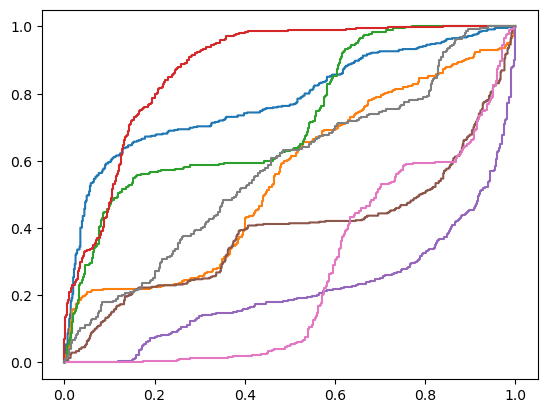

PI_MuLaTabICL_full_model_step-1000_probabilities_5_foldnew_loss.csv
ROC AUC:  0.8916280507619263


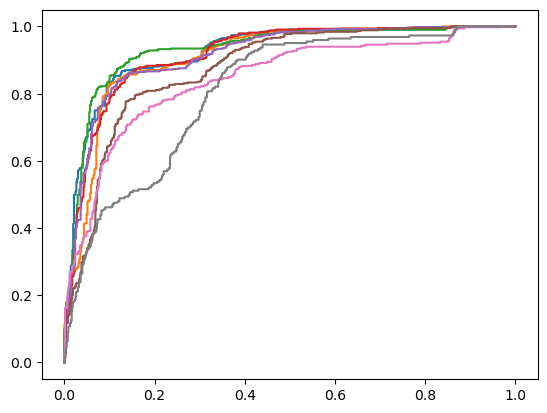

PI_MuLaTabICL_full_model_step-1000_probabilities_5_fold_new_loss_average_logits.csv
ROC AUC:  0.9078545108651965


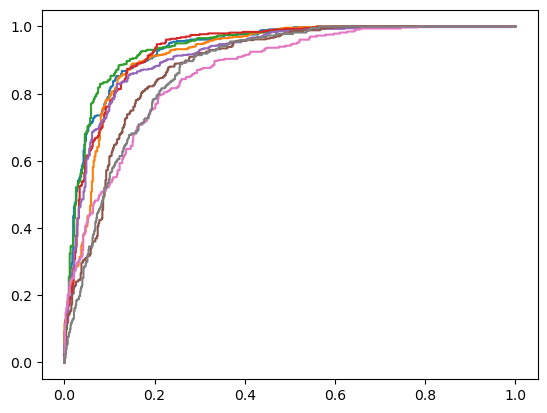

PI_Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv
ROC AUC:  0.9779292708733489


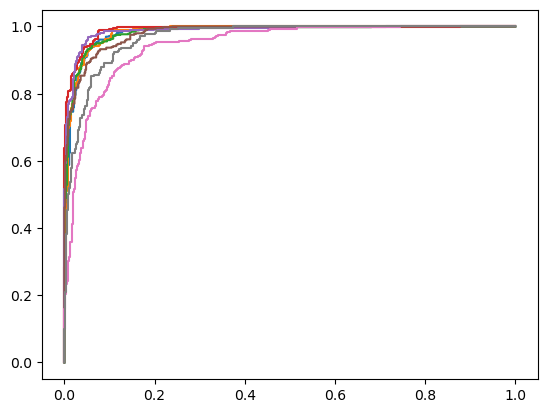

In [54]:
import matplotlib.pyplot as plt

files= ["./prediction_results/PI_results/PI_MuLaTabICL_full_model_step-1000.ckpt_probabilities_5_fold.csv","./prediction_results/PI_results/PI_MuLaTabICL_full_model_step-1000_probabilities_5_foldnew_loss.csv", "./prediction_results/PI_results/PI_MuLaTabICL_full_model_step-1000_probabilities_5_fold_new_loss_average_logits.csv", "./prediction_results/PI_results/PI_Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv"]

for file in files:

    print(file.split("/")[-1])
    df = pd.read_csv(file)


    true_labels = df.filter(regex="True_*")
    pred_proba = df.filter(regex="Pred_*")

    true_label_arr = np.array(true_labels)
    pred_proba_arr = np.array(pred_proba)

    fig, ax = plt.subplots()

    for r in range(true_label_arr.shape[1]):
        fpr, tpr, thresholds = roc_curve(true_label_arr[:,r], pred_proba_arr[:,r], pos_label=1)

        ax.plot(fpr, tpr)

    print("ROC AUC: ",roc_auc_score(true_labels, pred_proba))
    plt.show()


In [68]:
df = pd.read_csv("./prediction_results/PI_results/PI_MuLaTabICL_full_model_step-1000_probabilities_5_fold_new_loss_average_logits.csv")


true_labels = df.filter(regex="True_*")
pred_proba = df.filter(regex="Pred_*")

print(max(pred_proba.max()), min(pred_proba.min()))

true_label_arr = np.array(true_labels)
pred_proba_arr = np.array(pred_proba)


pred_labels = (pred_proba - pred_proba.mean()) / pred_proba.std()

#pred_labels= (pred_proba - min(pred_proba.min())) / (max(pred_proba.max()) - min(pred_proba.min()))

pred_labels = (pred_labels > 0.0) * 1.0

print(pred_labels)

sub_acc = result_handler.exam_acc(pd.DataFrame(pred_labels), true_labels)

sub_acc
#roc_auc_score(true_labels, pred_proba)

1.800537109375 -0.041229248046875
      Pred_Proba_FPV  Pred_Proba_ATV  Pred_Proba_IDV  Pred_Proba_LPV  \
0                0.0             1.0             0.0             0.0   
1                1.0             1.0             1.0             1.0   
2                1.0             1.0             1.0             1.0   
3                0.0             0.0             0.0             0.0   
4                0.0             0.0             0.0             0.0   
...              ...             ...             ...             ...   
1021             1.0             1.0             1.0             1.0   
1022             1.0             1.0             1.0             1.0   
1023             1.0             1.0             1.0             1.0   
1024             0.0             1.0             0.0             1.0   
1025             1.0             1.0             1.0             1.0   

      Pred_Proba_NFV  Pred_Proba_SQV  Pred_Proba_TPV  Pred_Proba_DRV  
0                1.0          

0.7746101364522417

In [70]:
df = pd.read_csv("./prediction_results/PI_results/PI_MuLaTabICL_full_model_step-1000_probabilities_5_fold_new_loss_average_logits.csv")


true_labels = df.filter(regex="True_*")
pred_proba = df.filter(regex="Pred_*")

#print(max(pred_proba.max()), min(pred_proba.min()))

true_label_arr = np.array(true_labels)
pred_proba_arr = np.array(pred_proba)


for i in range(int(min(pred_proba.min()) * 10), int(max(pred_proba.max()) * 10)):

    j = i * 0.1

    print("Threshold: ", j)


    #pred_labels= (pred_proba - min(pred_proba.min())) / (max(pred_proba.max()) - min(pred_proba.min()))

    pred_labels = (pred_proba > j) * 1.0

    sub_acc = result_handler.exam_acc(pd.DataFrame(pred_labels), true_labels)

    print(sub_acc)
    #roc_auc_score(true_labels, pred_proba)

Threshold:  0.0
0.425682261208577
Threshold:  0.1
0.42884990253411304
Threshold:  0.2
0.4331140350877193
Threshold:  0.30000000000000004
0.4401803118908382
Threshold:  0.4
0.4500487329434698
Threshold:  0.5
0.4640594541910331
Threshold:  0.6000000000000001
0.49317738791423
Threshold:  0.7000000000000001
0.5333820662768031
Threshold:  0.8
0.5783382066276803
Threshold:  0.9
0.629995126705653
Threshold:  1.0
0.6755604288499025
Threshold:  1.1
0.7219785575048733
Threshold:  1.2000000000000002
0.7703460038986355
Threshold:  1.3
0.8010477582846004
Threshold:  1.4000000000000001
0.7978801169590644
Threshold:  1.5
0.7212475633528265
Threshold:  1.6
0.6692251461988304
Threshold:  1.7000000000000002
0.6046539961013645


In [13]:
from MultiLabelPFN.src.tabicl.prior.dataset import PriorDataset

from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split


def remove_empty_columns(arr):

    df = pd.DataFrame(arr)


    df.replace(0, np.nan, inplace=True)
    df.replace(0.0, np.nan, inplace=True)

    df.dropna(how='all', axis=1, inplace=True)

    df.replace(np.nan, 0.0, inplace=True)

    return np.array(df)


def calc_threshold(classifier, prior_config):

    dataset = PriorDataset(**prior_config)

    batch_X, batch_y, _, _, _ = dataset.get_batch()

    #print(batch_X.shape)
    #print(batch_y.shape)

    batch_thresholds = []

    for d in range(batch_X.shape[0]):
        ds_X = batch_X[d]
        ds_y = batch_y[d]


        """for i in range(ds_X.shape[1]):
            if len(np.unique(ds_X[:,i])) == 1:
                print("Empty X: ", i)

        for i in range(ds_y.shape[1]):
            if len(np.unique(ds_y[:,i])) == 1:
                print("Empty Y: ", i)"""

        ds_X = remove_empty_columns(ds_X)
        ds_y = remove_empty_columns(ds_y)

        X_train, X_test, y_train, y_test = train_test_split(ds_X, ds_y, test_size=0.33, random_state=42)


        trained_model_pfn = classifier.fit(X_train, y_train)

        y_pred_proba = np.array(trained_model_pfn.predict_proba(X_test))

        #print(y_pred_proba.shape)
        #print(len(y_pred_proba.shape))

        if len(y_pred_proba.shape) == 3:
            y_pred_proba = y_pred_proba[...,1].T


        thresholds = []

        for r in range(y_test.shape[1]):

            fpr, tpr, thrs = roc_curve(y_test[:,r], y_pred_proba[:,r])
            #print("Label: ", r)


            opti = tpr - fpr

            thr_i = np.argmax(opti)

            if thrs[thr_i] == np.inf:
                print("Inf")

            thresholds.append(thrs[thr_i])



        batch_thresholds.append(np.mean(thresholds))

    overall_mean_threshold = np.mean(batch_thresholds)


    return overall_mean_threshold



config_dict = {
    "batch_size": 128,
    "batch_size_per_gp": 4,
    "min_features": 2,
    "max_features": 100,
    "max_labels": 10,
    "min_quan": 0.5,
    "max_quan": 0.95,
    #"min_seq_len": config.min_seq_len,
    "max_seq_len": 1024,
    #"log_seq_len": config.log_seq_len,
    #"seq_len_per_gp": config.seq_len_per_gp,
    #"min_train_size": config.min_train_size,
    #"max_train_size": config.max_train_size,
    #"replay_small": config.replay_small,
    "prior_type": "mix_scm",
    #"device": config.prior_device,
}
'''
dataloader_config = {"n_jobs": 1,  # Set to 1 to avoid nested parallelism during DDP
    "batch_size": None,  # No additional batching since PriorDataset handles batching internally
    "shuffle": False,
    "num_workers": 1,
    "prefetch_factor": 4,
    #"pin_memory": True if config.prior_device == "cpu" else False,
    #"pin_memory_device": config.device if config.prior_device == "cpu" else "",
     }'''

#multi_target_pfn = TabICLClassifier(model_path="../my/" + model, allow_auto_download=False,
#average_logits=True, n_jobs=2, verbose=True, use_hierarchical=False)

lr = LogisticRegression()
br_lr = MultiOutputClassifier(lr, n_jobs=2)


test8 = calc_threshold(br_lr, config_dict)

print(test8)

0.29110388478100296


In [19]:
import numpy as np
import pandas as pd
import prediction_handler as result_handler

thrsh1 =  0.7548192
thrsh2 = 0.59634644


pred_BR_LR = pd.read_csv("./prediction_results/PI_results/PI_MuLaTabICL_full_model_step-1000.ckpt_5_fold.csv")
pred_proba_BR_LR = pd.read_csv("./prediction_results/PI_results/PI_MuLaTabICL_full_model_step-1000_probabilities_5_foldnew_loss.csv")

true_labels = pred_BR_LR.filter(regex="True_*")
pred = pred_BR_LR.filter(regex="Pred_*")
pred_proba = pred_proba_BR_LR.filter(regex="Pred_*")
#print(max(pred_proba.max()), min(pred_proba.min()))

true_label_arr = np.array(true_labels)
pred_proba_arr = np.array(pred_proba)


pred_labels = (pred_proba > thrsh1) * 1.0

sub_acc = result_handler.exam_acc(pred, true_labels)

print(sub_acc)

sub_acc = result_handler.exam_acc(pd.DataFrame(pred_labels), true_labels)

print(sub_acc)

pred_labels = (pred_proba > thrsh2) * 1.0

sub_acc = result_handler.exam_acc(pd.DataFrame(pred_labels), true_labels)

print(sub_acc)

0.5752923976608187
0.7613304093567251
0.4247076023391813


In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import prediction_handler as result_handler
import os
from sklearn.metrics import jaccard_score, roc_auc_score
import result_handler

#setting filepaths of the results

pi_results_filepath = "./prediction_results/PI_results/PI_"

nnrti_results_filepath = "./prediction_results/NNRTI_results/NNRTI_"

nrti_results_filepath = "./prediction_results/NRTI_results/NRTI_"

ini_results_filepath = "./prediction_results/INI_results/INI_"



#creating lists with filepaths for later visualisation
filepath_list = [pi_results_filepath, nnrti_results_filepath, nrti_results_filepath, ini_results_filepath]

modeltype = "MuLaTabICL_"

models = [
    "finetune_step-1250",
    "finetune_stage3_step-50",
    "bal_prior_step-1000",
    "finetune_step-2000",
    "bal_prior_step-1350",
    "finetune_step-3150",
    "full_model_step-1000",
    "abicl-classifier-v1.1-0506",
    "random_test/step-1"]

ending = "_5_fold_new_loss_sigmoid.csv"

thrshlds_internal = {"finetune_step-1250":  0.6860411,
"bal_prior_step-1000":  0.5292327,
"finetune_step-2000":  0.747135,
"bal_prior_step-1350":  0.504576,
"finetune_step-3150":  0.67952967,
"full_model_step-1000":  0.581367369,
"abicl-classifier-v1.1-0506":  0.709058,
"random_test/step-1":  np.nan,}

thrshlds_temp_sig = {"finetune_step-1250":  0.7540253,
"bal_prior_step-1000":  0.52958435,
"finetune_step-2000":  0.79760474,
"bal_prior_step-1350":  0.5100705,
"finetune_step-3150":  0.67292804,
"full_model_step-1000":  0.748620175,
"abicl-classifier-v1.1-0506":  0.7361159,
"random_test/step-1":  np.nan,}

thrshlds_temp_sig_new = {"finetune_step-1250":  0.6830695,
"finetune_stage3_step-50":  0.62230235,
"bal_prior_step-1000":  0.53245866,
"finetune_step-2000":  0.721869,
"bal_prior_step-1350":  0.5226037,
"finetune_step-3150":  0.82249993,
"full_model_step-1000":  0.73285752,
"abicl-classifier-v1.1-0506":  0.7113368,
"random_test/step-1":  np.nan,}


In [21]:

results = []


for path in filepath_list:



    roc_auc = []
    prc_auc = []
    old_acc = []
    exac_int = []
    exac_tmp = []
    exac_new = []



    print("============" + path.split("/")[-1].strip("_") + "============")

    for model in models:

        print(model)

        pred = pd.read_csv(path + modeltype + model + ending)
        pred_proba = pd.read_csv(path + modeltype + model + "_probabilities" + ending)

        true_labels = pred.filter(regex="True_*")
        pred_labels_old = pred.filter(regex="Pred_*")
        pred_proba = pred_proba.filter(regex="Pred_*")
        #print(max(pred_proba.max()), min(pred_proba.min()))

        true_label_arr = np.array(true_labels)
        pred_proba_arr = np.array(pred_proba)

        roc_auc.append(roc_auc_score(true_label_arr, pred_proba_arr))
        prc_auc.append(result_handler.prc_auc_score(true_label_arr, pred_proba_arr, multiclass="ovr"))

        old_acc.append(result_handler.exam_acc(pred_labels_old, true_labels))

        if model in list(thrshlds_internal.keys()):
            pred_labels_new = (pred_proba > thrshlds_internal[model]) * 1.0

            exac_int.append(result_handler.exam_acc(pred_labels_new, true_labels))
        else:
            exac_int.append(np.nan)

        if model in list(thrshlds_temp_sig.keys()):
            pred_labels_new = (pred_proba > thrshlds_temp_sig[model]) * 1.0

            exac_tmp.append(result_handler.exam_acc(pred_labels_new, true_labels))
        else:
            exac_tmp.append(np.nan)

        pred_labels_new = (pred_proba > thrshlds_temp_sig_new[model]) * 1.0

        exac_new.append(result_handler.exam_acc(pred_labels_new, true_labels))


    model_results= {"ROC AUC":roc_auc,
                                 "PRC AUC":prc_auc,
                                 "Base Acc": old_acc,
                                 "Internal Acc":exac_int,
                                 "W Temp Acc":exac_tmp,
                                 "New W Temp Acc":exac_new}

    results.append(model_results)


============PI============
finetune_step-1250
finetune_stage3_step-50
bal_prior_step-1000
finetune_step-2000
bal_prior_step-1350
finetune_step-3150
full_model_step-1000
abicl-classifier-v1.1-0506
random_test/step-1
============NNRTI============
finetune_step-1250
finetune_stage3_step-50
bal_prior_step-1000
finetune_step-2000
bal_prior_step-1350
finetune_step-3150
full_model_step-1000
abicl-classifier-v1.1-0506
random_test/step-1
============NRTI============
finetune_step-1250
finetune_stage3_step-50
bal_prior_step-1000
finetune_step-2000
bal_prior_step-1350
finetune_step-3150
full_model_step-1000
abicl-classifier-v1.1-0506
random_test/step-1
============INI============
finetune_step-1250
finetune_stage3_step-50
bal_prior_step-1000
finetune_step-2000
bal_prior_step-1350
finetune_step-3150
full_model_step-1000
abicl-classifier-v1.1-0506
random_test/step-1


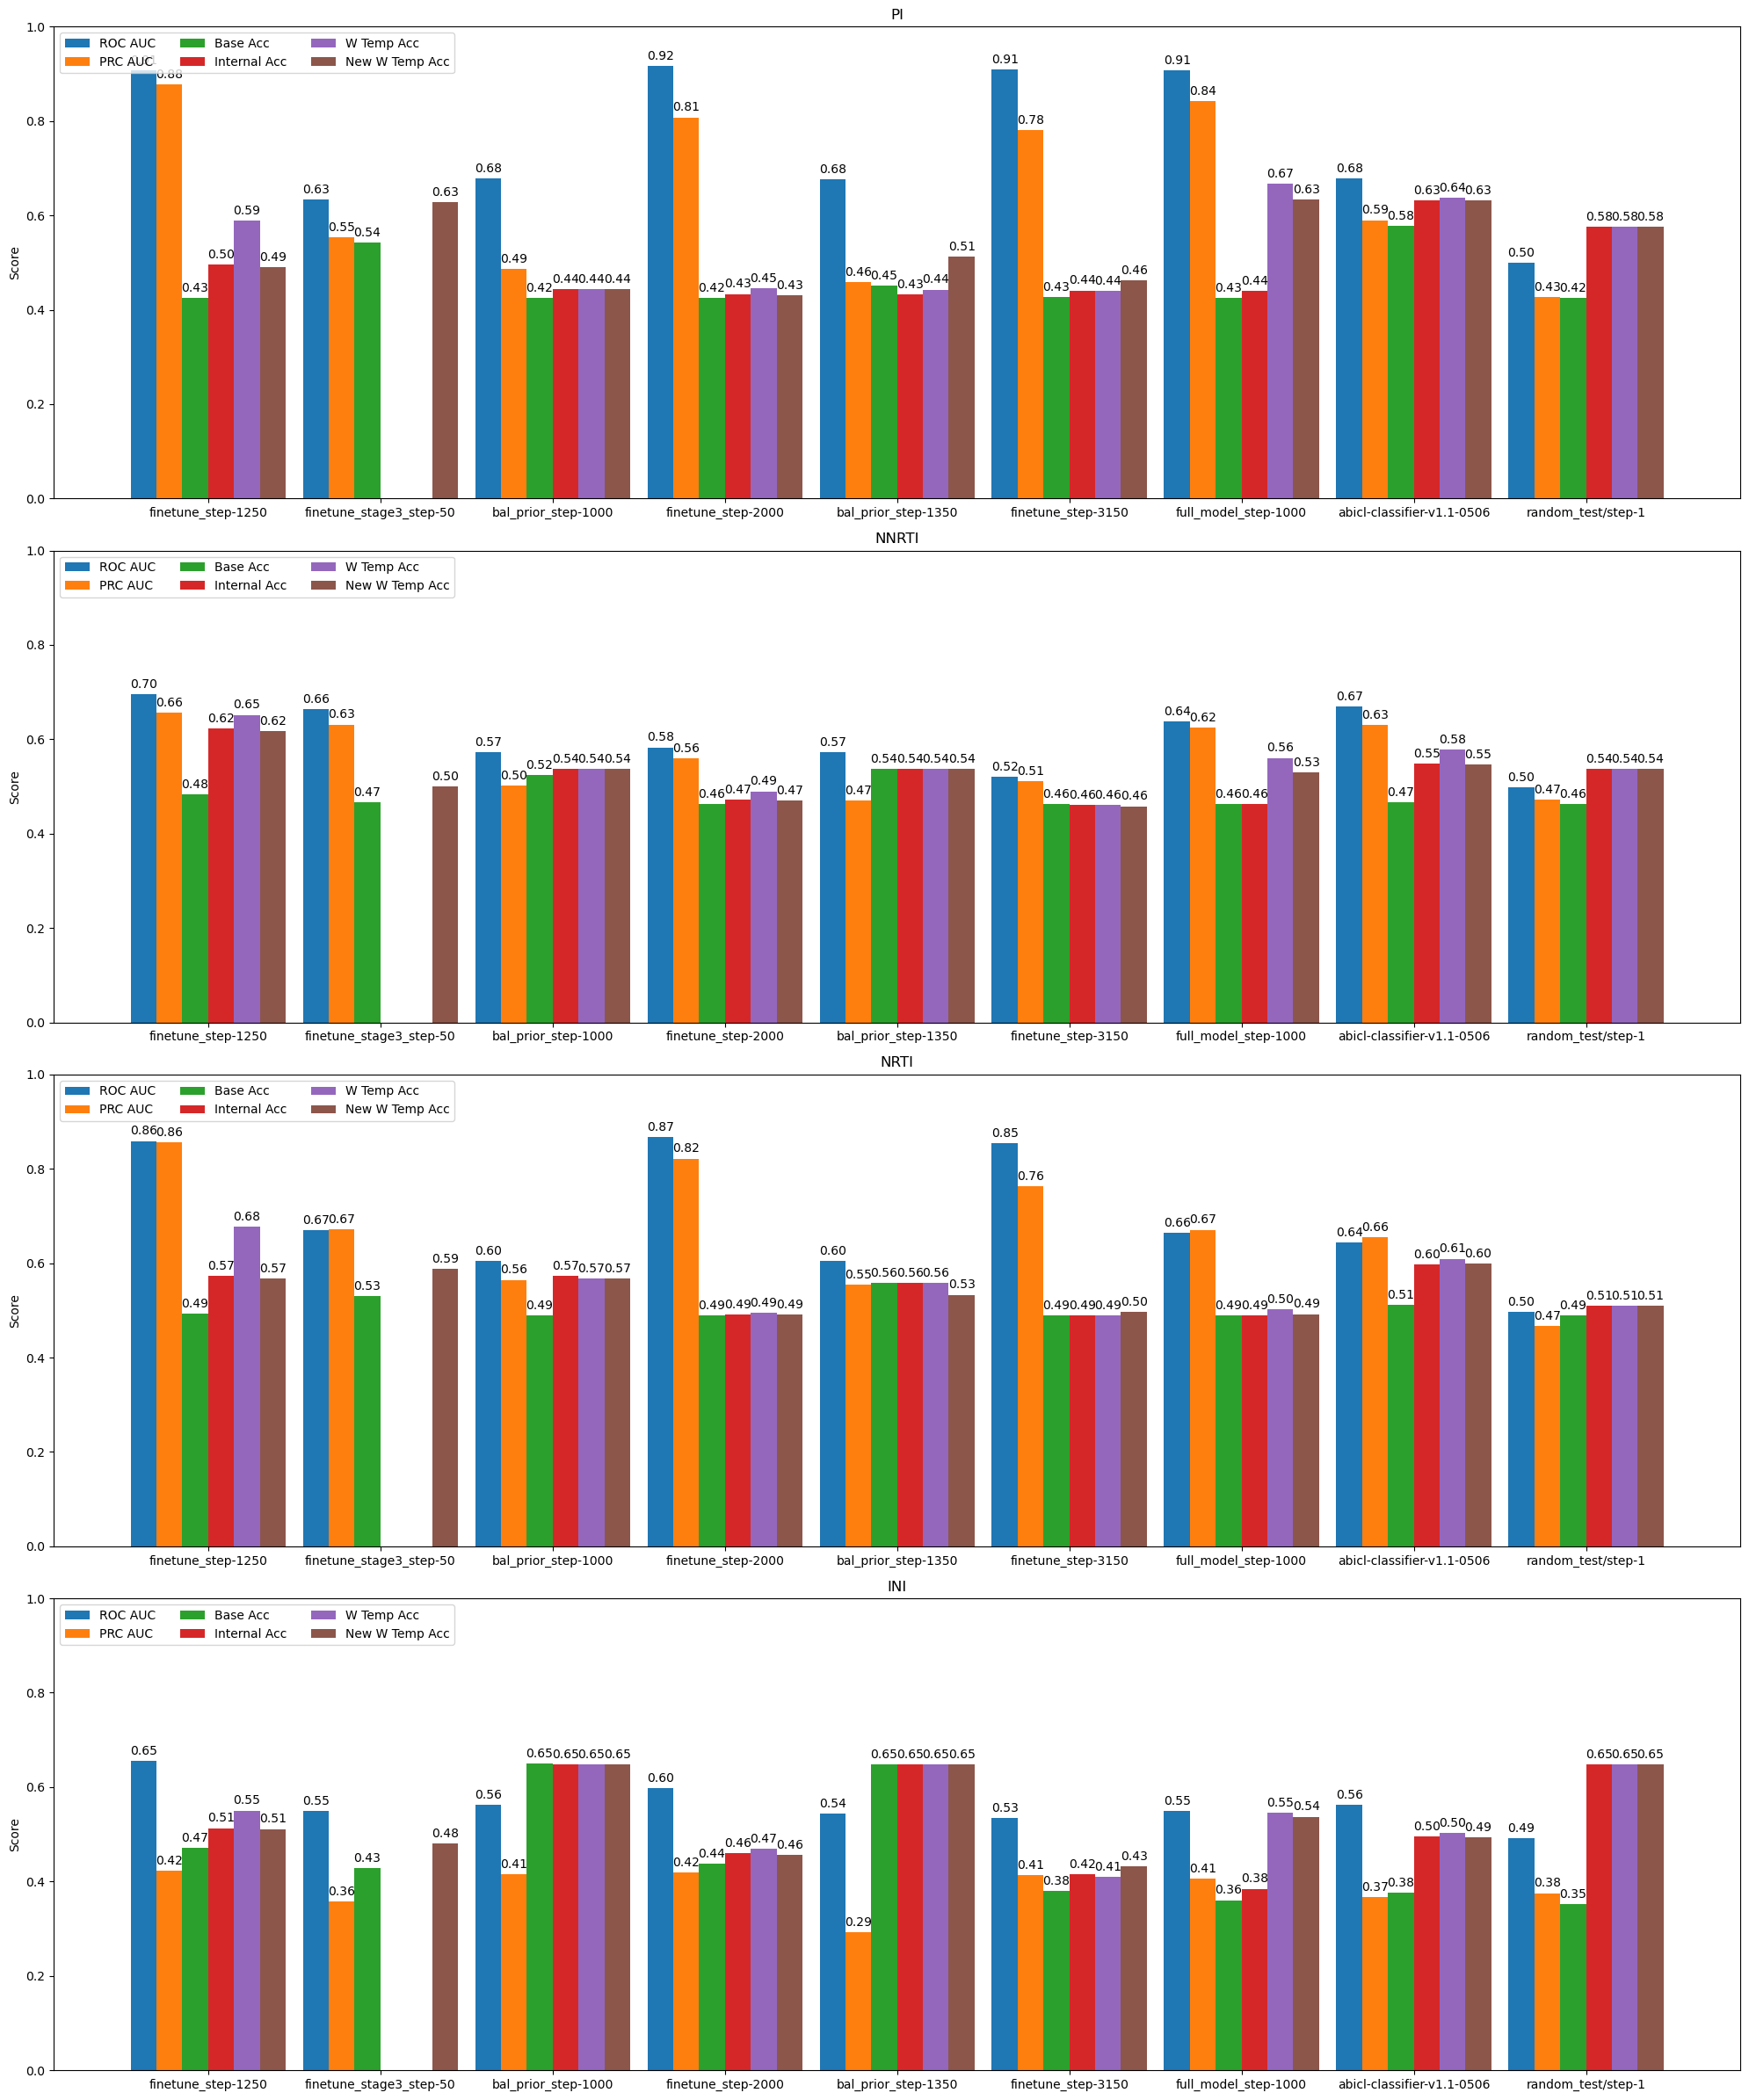

In [36]:

import numpy as np

x = np.arange(len(models))  # the label locations
width = 0.15  # the width of the bars

fig, axs = plt.subplots(4, figsize=(20, 24),layout='tight')

for i, path in enumerate(filepath_list):

    multiplier = -1.5

    ax = axs[i]

    for attribute, measurement in results[i].items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, fmt='%.2f', padding=3)
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Score')
    ax.set_title(path.split("/")[-1].strip("_"))
    ax.set_xticks(x + width, models)
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, 1)

plt.show()

In [14]:

for path in filepath_list:

    acc_list_mean = []
    acc_list_std = []

    print("============" + path.split("/")[-1].strip("_") + "============")

    for model in models:

        print(model)

        pred = pd.read_csv(path + modeltype + model + ending)
        pred_proba = pd.read_csv(path + modeltype + model + "_probabilities" + ending)

        true_labels = pred.filter(regex="True_*")
        pred_labels_old = pred.filter(regex="Pred_*")
        pred_proba = pred_proba.filter(regex="Pred_*")
        #print(max(pred_proba.max()), min(pred_proba.min()))

        true_label_arr = np.array(true_labels)
        pred_proba_arr = np.array(pred_proba)

        print("AUC ROC: ", roc_auc_score(true_label_arr, pred_proba_arr))




============PI============
finetune_step-1250
AUC ROC:  0.9071722218447218
finetune_stage3_step-50
AUC ROC:  0.63313699277589
bal_prior_step-1000
AUC ROC:  0.6784114559541663
finetune_step-2000
AUC ROC:  0.9170794693648017
bal_prior_step-1350
AUC ROC:  0.6766394962961199
finetune_step-3150
AUC ROC:  0.9085250241189418
full_model_step-1000
AUC ROC:  0.9078545108651965
abicl-classifier-v1.1-0506
AUC ROC:  0.677915555592626
random_test/step-1
AUC ROC:  0.4997526786059179
============NNRTI============
finetune_step-1250
AUC ROC:  0.6952548662477358
finetune_stage3_step-50
AUC ROC:  0.6645218501233491
bal_prior_step-1000
AUC ROC:  0.5721753264021554
finetune_step-2000
AUC ROC:  0.5829822687012988
bal_prior_step-1350
AUC ROC:  0.5722615618640872
finetune_step-3150
AUC ROC:  0.5197674291172624
full_model_step-1000
AUC ROC:  0.6380336785215157
abicl-classifier-v1.1-0506
AUC ROC:  0.6695566427562223
random_test/step-1
AUC ROC:  0.4979655553339639
============NRTI============
finetune_step-1250


In [7]:
import numpy as np
import pandas as pd
import prediction_handler as result_handler

thrsh1 = 0.30429304246040617

pred_BR_LR = pd.read_csv("./prediction_results/PI_results/benchmarkings/PI_BR_LR.csv")
pred_proba_BR_LR = pd.read_csv("./prediction_results/PI_results/benchmarkings/PI_BR_LR_probabilities.csv")

true_labels = pred_BR_LR.filter(regex="True_*")
pred = pred_BR_LR.filter(regex="Pred_*")
pred_proba = pred_proba_BR_LR.filter(regex="Pred_*")
#print(max(pred_proba.max()), min(pred_proba.min()))

true_label_arr = np.array(true_labels)
pred_proba_arr = np.array(pred_proba)


pred_labels = (pred_proba > thrsh1) * 1.0

sub_acc = result_handler.exam_acc(pred, true_labels)

print(sub_acc)

sub_acc = result_handler.exam_acc(pd.DataFrame(pred_labels), true_labels)

print(sub_acc)

0.9365781710914455
0.9325221238938053


In [18]:
print(test8[0].shape)
print(test8[1])

torch.Size([8, 1024, 100])
tensor([[[0., 1., 1.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 1., 1.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [1., 1., 0.,  ..., 0., 0., 0.],
         [0., 0., 1.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 1.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 1., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [1., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[1., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 

In [31]:
import pandas as pd
import prediction_handler as result_handler
from sklearn.metrics import roc_auc_score, roc_curve

def sigmoid(x, temperature: float = 0.9):
    """Compute sigmoid values with temperature scaling using NumPy.

    Parameters
    ----------
    x : ndarray
        Input array of logits.

    axis : int, default=-1
        Axis along which to compute softmax.

    temperature : float, default=0.9
        Temperature scaling parameter.

    Returns
    -------
    ndarray
        Softmax probabilities along the specified axis, with the same shape as the input.
    """
    x = x / temperature
    # Subtract max for numerical stability
    #x_max = np.max(x, axis=axis, keepdims=True)
    e_x = np.exp(-x)
    # Compute softmax
    return 1 / ( 1 + e_x)

df = pd.read_csv("./prediction_results/PI_results/PI_MuLaTabICL_full_model_step-1000_probabilities_5_fold_new_loss_average_logits.csv")


true_labels = df.filter(regex="True_*")
pred_proba = df.filter(regex="Pred_*")



true_label_arr = np.array(true_labels)
pred_proba_arr = np.array(pred_proba)


pred_labels = sigmoid(pred_proba_arr)

thresholds = []

for r in range(true_label_arr.shape[1]):
    fpr, tpr, thrs = roc_curve(true_label_arr[:,r], pred_proba_arr[:,r])
    print("Label: ", r)


    opti = tpr - fpr

    thr_i = np.argmax(opti)

    thresholds.append(thrs[thr_i])

print(np.mean(thresholds))

'''print(roc_auc_score(true_labels, pred_labels))

print(pred_labels)
#pred_labels= (pred_proba - min(pred_proba.min())) / (max(pred_proba.max()) - min(pred_proba.min()))

pred_labels = (pred_labels > 0.5) * 1.0

print(pred_labels)

sub_acc = result_handler.exam_acc(pd.DataFrame(pred_labels), true_labels)

sub_acc
#roc_auc_score(true_labels, pred_proba)'''

Label:  0
Label:  1
Label:  2
Label:  3
Label:  4
Label:  5
Label:  6
Label:  7
1.3292992115020752


'print(roc_auc_score(true_labels, pred_labels))\n\nprint(pred_labels)\n#pred_labels= (pred_proba - min(pred_proba.min())) / (max(pred_proba.max()) - min(pred_proba.min()))\n\npred_labels = (pred_labels > 0.5) * 1.0\n\nprint(pred_labels)\n\nsub_acc = result_handler.exam_acc(pd.DataFrame(pred_labels), true_labels)\n\nsub_acc\n#roc_auc_score(true_labels, pred_proba)'

In [52]:
test9 = pd.DataFrame(np.array( [[2, 1, 0, 0],
                                [1, 1, 0, 0],
                                [0, 0, 0, 0]], dtype=float))
print(test9)

test9.replace(0, np.nan, inplace=True)

test9.dropna(how='all', axis=1, inplace=True)

test9.replace(np.nan, 0, inplace=True)
print(test9)

     0    1    2    3
0  2.0  1.0  0.0  0.0
1  1.0  1.0  0.0  0.0
2  0.0  0.0  0.0  0.0
     0    1
0  2.0  1.0
1  1.0  1.0
2  0.0  0.0


In [69]:
import torch

test10 = np.ones((8, 338, 2))

#test10 = test10[...,1].squeeze(axis=2).T

test10 = test10[...,1].T

print(test10.shape)

(8, 338)


In [19]:
import torch

test11 = torch.zeros((2, 3, 4))

test11 = test11.transpose(1, 0)

test11.shape

torch.Size([3, 2, 4])